In [1]:
import sys, os, copy, torch
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Image


sys.path.append('../')

# # helpers
from paper_helpers.io.discover import paths_to_df, find_data_obj_files, condense_df
from paper_helpers.io.paths import build_save_base, predict_u_pred, build_save_path, hist_properties, hist_properties_wrapper

from paper_helpers.plotting.snapshots import DensitySnapshotPlotter
from paper_helpers.io.paths import rebase_to_training
from paper_helpers.plotting.density import MidlinePlotter
from paper_helpers.plotting.training_dynamics import TrainingDynamicsPlotter
from paper_helpers.plotting.loss_trajectories import EarlyStoppingTrajectoryPlotter
from paper_helpers.plotting.sr_eval import SRPlotter
from paper_helpers.simulation.forward_batch import run_forward_sr_batch
from paper_helpers.plotting.forward_eval import ForwardSimulationAnalysis, LegendConfig
from paper_helpers.sr.analysis import SymbolicRegressionSeedReporter

# # Add to main (v2 standalone)
from data.python_v2.modules import Data_experiment
from data.python_v2.components.pathing import dict_to_ordered_path as dictToPath

from binn_v2.python.Modules.Utils.ModelWrapper import ModelWrapper
from binn_v2.python.Modules.Models.BuildBINNs_2D import (BINN_2d, u_MLP, D_MLP, G_MLP,
                                                      pde_loss_without_bc_2d, data_loss_MSE,generate_random_inputs_2d)
from binn_v2.python.Modules.Models.BuildMLP import BuildMLP
from binn_v2.python.Modules.Utils.PDESolver_2D import PDE_sim_old_2d,PDE_RHS_2D
from paper_helpers.plotting.training_dynamics import TrainingDynamicsPlotter
import matplotlib as mpl

# Centralized output directories for JN_v2
OUTPUT_ROOT = "outputs"
FIGURES_ROOT = os.path.join(OUTPUT_ROOT, "figures")
FIGURES_MAIN_DIR = os.path.join(FIGURES_ROOT, "main")
FIGURES_SUPP_DIR = os.path.join(FIGURES_ROOT, "supplement")
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
SR_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, "sr")
FWD_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, "forward")
for _d in [OUTPUT_ROOT, FIGURES_ROOT, FIGURES_MAIN_DIR, FIGURES_SUPP_DIR, TABLES_DIR, SR_OUTPUT_DIR, FWD_OUTPUT_DIR]:
    os.makedirs(_d, exist_ok=True)
# Make all spines visible by default
mpl.rcParams['axes.spines.top'] = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.spines.bottom'] = True
mpl.rcParams['axes.spines.left'] = True

# Optional: style the border
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams["axes.grid"] = "False"
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['grid.linewidth'] = 0.5

## Load experimental data

In [2]:
# Settings to load experimental data 
# ==================================
gamma = 0
K = 1
x7 = 1

# Define the unique cases (replicates) by their x4_x5 combinations
keys = ["2_5", "2_3", "3_1"]
num_replicates = len(keys)

# Mapping configurations to each key
# Format: { key: [t0, Ts, x2opt, x3opt, x4, x5] }
configs = {
    "2_3": [8,  52, '0p0', '0p0', 2, 3],
    "2_5": [24, 56, '0p0', '0p0', 2, 5],
    "3_1": [4,  64, '0p0', '0p0', 3, 1]
}


speciesLabel = "green"

# --- Initialize Dictionaries ---
hoursRanges    = {}
xmins, xmaxs   = {}, {}
ymins, ymaxs   = {}, {}
dxs, dys       = {}, {}
speciesLabels  = {}
x2opts, x3opts = {}, {}
x4opts, x5opts = {}, {}
tinit          = {}

for k in keys:
    t_start, t_end, x2, x3, x4, x5 = configs[k]
    
    # Time settings
    hoursRanges[k]   = list(range(t_start, t_end + 1, 4))
    tinit[k]         = t_start
    
    # Metadata
    x2opts[k], x3opts[k] = x2, x3
    x4opts[k], x5opts[k] = x4, x5
    
    # Domain settings (constants for these replicates)
    xmins[k], xmaxs[k] = 0.0, 1410.0
    ymins[k], ymaxs[k] = 0.0, 1050.0
    dxs[k], dys[k]     = 100.0, 100.0
    speciesLabels[k]   = speciesLabel 

In [3]:
# --- Setup Paths ---
initial_path = os.path.join("../dataObj_v2")
raw_data_df = paths_to_df(find_data_obj_files(start_dir=initial_path, target_filename="data_obj.npy"))

# --- Containers ---
dataObj_dict = {}
dataInfo_dict = {}
# We use case_keys from the previous step as our source of truth
keys = list(hoursRanges.keys()) 

# --- Processing ---
for key in keys:
    # Build data_info pulling directly from our dictionaries using the key
    
    
    data_info = {
        "speciesLabel": speciesLabels[key],
        "x2opt": x2opts[key],
         "x3opt": x3opts[key],
         "x4opt": x4opts[key],
         "x5opt": x5opts[key],
         "x7": x7,
          "dx": dxs[key],
          "dy": dys[key],
          "xmin": xmins[key],
         "ymin": ymins[key],
         "xmax": xmaxs[key],
         "ymax": ymaxs[key],
         "hoursRange": hoursRanges[key],
          "gamma": gamma,
          "K": K,
    }

    # Extract and Load Data
    data_df_updated = condense_df(raw_data_df.copy(), data_info)

    
    
    
    if not data_df_updated.empty:
        data_path = data_df_updated["full_path"].iloc[0]
        dataObj_dict[key] = np.load(data_path, allow_pickle=True).item()
        dataInfo_dict[key] = data_info
    else:
        print(f"Warning: No data found for key {key}")

# --- Data Summary ---
print("\n--- Data Summary ---")
for k in dataObj_dict:
    shape = dataObj_dict[k].u_green.shape
    print(f"Key: {k:10} | Shape: {shape}")


--- Data Summary ---
Key: 2_5        | Shape: (15, 11, 9)
Key: 2_3        | Shape: (15, 11, 12)
Key: 3_1        | Shape: (15, 11, 16)


## Data plots

Processing key: 2_5


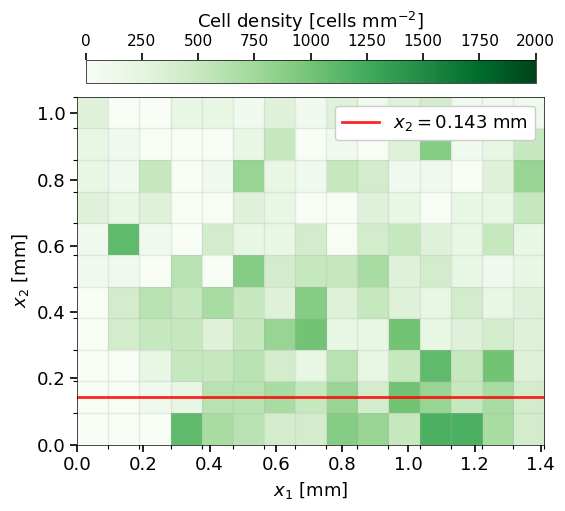

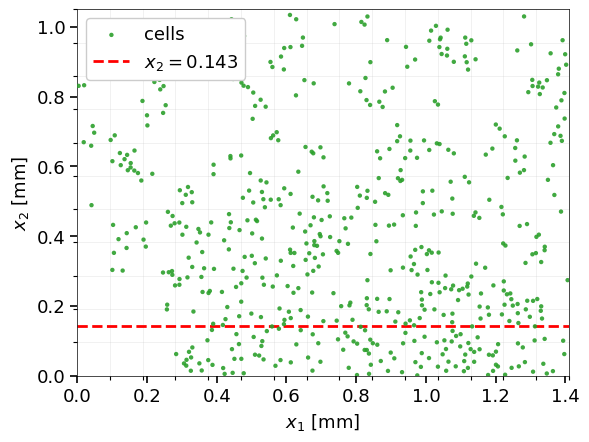

[2_5] Saved heatmap: outputs/figures/supplement/x4_2_x5_5/density_heatmap_slice_green_t0000.png
[2_5] Saved scatter: outputs/figures/supplement/x4_2_x5_5/positions_scatter_t0000.png
Processing key: 2_3


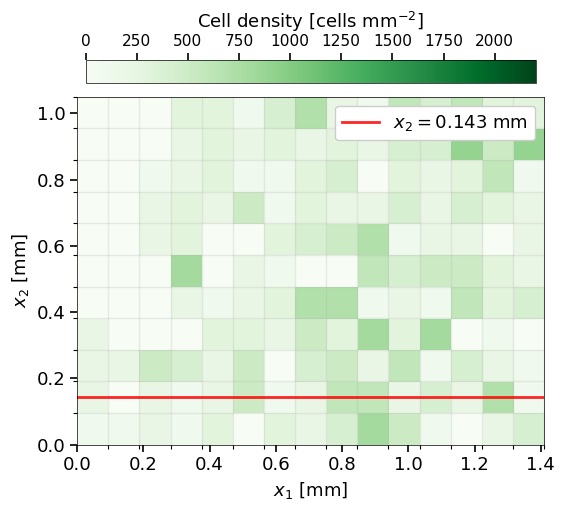

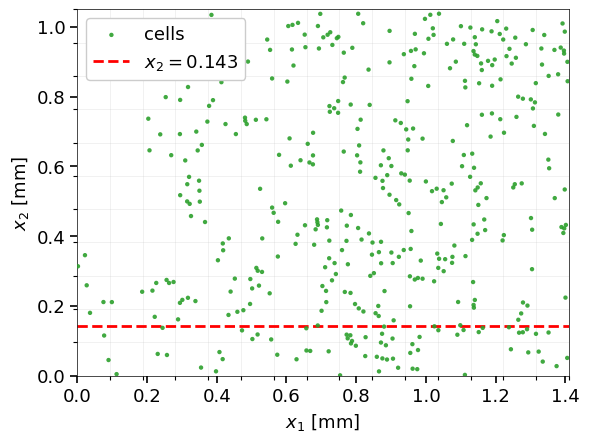

[2_3] Saved heatmap: outputs/figures/supplement/x4_2_x5_3/density_heatmap_slice_green_t0000.png
[2_3] Saved scatter: outputs/figures/supplement/x4_2_x5_3/positions_scatter_t0000.png
Processing key: 3_1


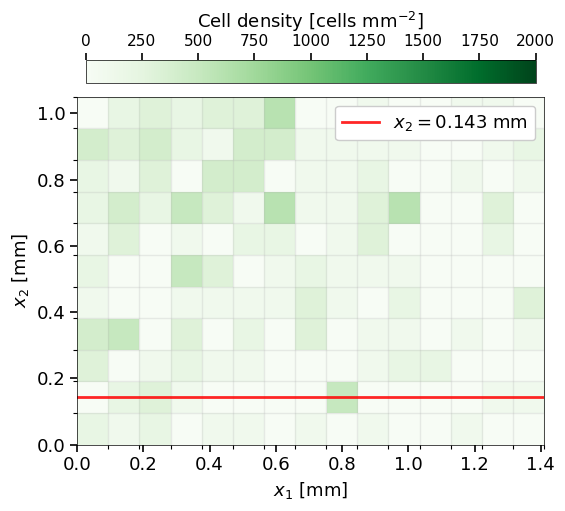

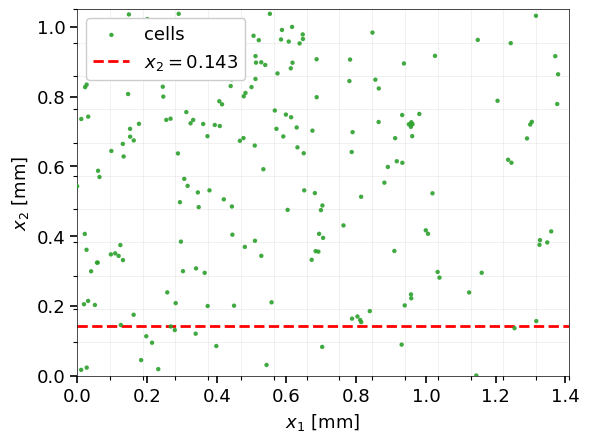

[3_1] Saved heatmap: outputs/figures/supplement/x4_3_x5_1/density_heatmap_slice_green_t0000.png
[3_1] Saved scatter: outputs/figures/supplement/x4_3_x5_1/positions_scatter_t0000.png


In [4]:
# =============
# Paper Plot Loop
# =============

# Iterating over every key in the keys list
for key in keys:
    print(f"Processing key: {key}")

    # Extract data for the current key
    data_info = dataInfo_dict[key]
    x4opt_save = data_info["x4opt"]
    x5opt_save = data_info["x5opt"]
    data_obj = dataObj_dict[key]

    # Create a unique directory for this specific key/parameter set
    save_path = os.path.join(FIGURES_SUPP_DIR, f"x4_{x4opt_save}_x5_{x5opt_save}")
    os.makedirs(save_path, exist_ok=True)

    # Initialize the plotter for this directory
    plotter = DensitySnapshotPlotter(
        out_dir=save_path,
        overwrite_existing=True,
        show=True,
        save_dpi=100,
    )

    # 1. Generate Density Heatmap and Scatter Snapshots
    heat_png, scatter_png = plotter.make_density_heatmap_and_scatter_snapshots(
        data_obj=data_obj,
        ix=None,
        iy=1,
        species=speciesLabel,
        t_index=0,
        figsizes=((6, 5), (6, 5)),
        legend_fontsize=13,
        legend_loc_heatmap="upper right",
        legend_loc_scatter="upper left",
        xlabel_fontsize=13.0,
        ylabel_fontsize=13.0,
        xtick_labelsize=13,
        ytick_labelsize=13,
        title_fontsize=11,
        major_tick_length=5.0,
        major_tick_width=1.2,
        minor_tick_length=3.0,
        minor_tick_width=0.8,
        legend_kwargs={"framealpha": 1},
        cbar_label_fontsize=13.0,
        cbar_tick_fontsize=11,
        cbar_shrink=0.8,
        cbar_fraction=0.1,
        
    )

    print(f"[{key}] Saved heatmap: {heat_png}")
    print(f"[{key}] Saved scatter: {scatter_png}")

    


In [5]:
# saved_by_time = plotter.make_green_cell_scatter_snapshots_for_times_with_keys_as_subplots(
#     data_obj_dict=dataObj_dict,
#     keys=keys,
#     time_array=range(4,64+1,4),
#     ix=None,
#     iy=1,
#     show_slice_lines=True,
#     figsize_per_panel=(4.5, 4.0),
#     mapping_dict={"2_5": "repl.1", "2_3": "repl.2","3_1": "repl.3"}, # Add your mapping dictionary here
# )


# saved_by_time_rel = plotter.make_green_cell_scatter_snapshots_for_relative_times_with_keys_as_subplots(
#     data_obj_dict=dataObj_dict,
#     keys=keys,
#     relative_time_array=range(0, 60 + 1, 4), # Now interpreted as hours AFTER t0
#     ix=None,
#     iy=1,
#     show_slice_lines=True,
#     figsize_per_panel=(4.5, 4.0),
#     mapping_dict={"2_5": "repl.1", "2_3": "repl.2", "3_1": "repl.3"}, 
#     highlight_dense_squares=True,
#     density_threshold = 1000.0,
# )


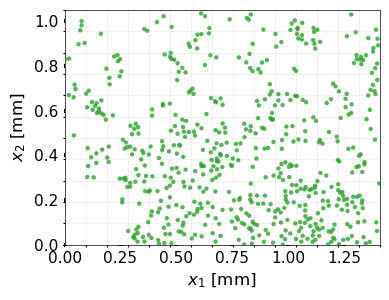

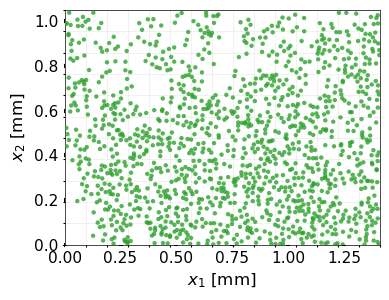

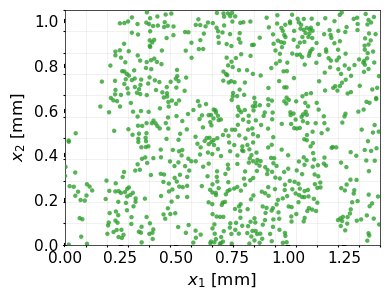

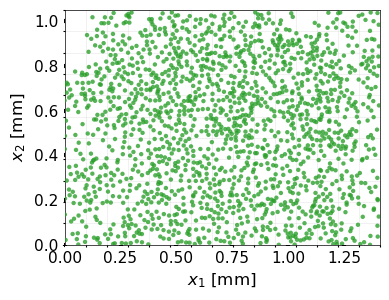

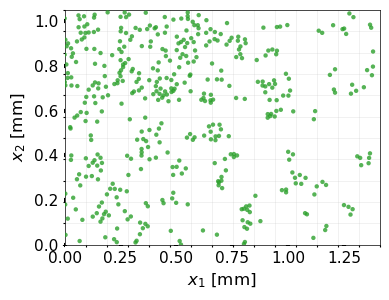

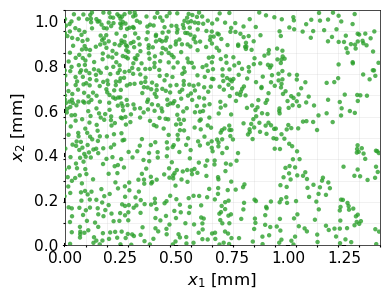

2_5 24.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_5__req_24p0h__used_24h.png
2_5 48.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_5__req_48p0h__used_48h.png
2_3 24.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_3__req_24p0h__used_24h.png
2_3 48.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_3__req_48p0h__used_48h.png
3_1 24.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_3_1__req_24p0h__used_24h.png
3_1 48.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_3_1__req_48p0h__used_48h.png


In [6]:
# KEEP
saved = plotter.make_green_cell_scatter_snapshots_individually_for_keys_and_times(
    data_obj_dict=dataObj_dict,
    keys=keys,
    time_array=[24, 48],
    ix=None,
    iy=1,
    show_slice_lines=False,
    xlabel_fontsize=12.0,
    ylabel_fontsize=12.0,
    xtick_labelsize=11,
    ytick_labelsize=11,
    title_fontsize=0,
    major_tick_length=1.0,
    major_tick_width=3,
    minor_tick_length=1.5,
    minor_tick_width=0.8,
)

for key, time_map in saved.items():
    for req_t, path in time_map.items():
        print(key, req_t, "->", path)

In [7]:

# Settings to load experimental data 
# ==================================
gamma = 0
K = 1
x7 = 1

# Define the unique cases (replicates) by their x4_x5 combinations
keys = ["2_3", "2_5", "3_1"]
num_replicates = len(keys)

# Mapping configurations to each key
# Format: { key: [t0, Ts, x2opt, x3opt, x4, x5] }
configs = {
    "2_3": [8,  52, '0p0', '0p0', 2, 3],
    "2_5": [24, 56, '0p0', '0p0', 2, 5],
    "3_1": [4,  64, '0p0', '0p0', 3, 1]
}


speciesLabel = "green"

# --- Initialize Dictionaries ---
hoursRanges    = {}
xmins, xmaxs   = {}, {}
ymins, ymaxs   = {}, {}
dxs, dys       = {}, {}
speciesLabels  = {}
x2opts, x3opts = {}, {}
x4opts, x5opts = {}, {}
tinit          = {}

for k in keys:
    t_start, t_end, x2, x3, x4, x5 = configs[k]
    
    # Time settings
    hoursRanges[k]   = list(range(t_start, t_end + 1, 4))
    tinit[k]         = t_start
    
    # Metadata
    x2opts[k], x3opts[k] = x2, x3
    x4opts[k], x5opts[k] = x4, x5
    
    # Domain settings (constants for these replicates)
    xmins[k], xmaxs[k] = 0.0, 1410.0
    ymins[k], ymaxs[k] = 0.0, 1050.0
    dxs[k], dys[k]     = 100.0, 100.0
    speciesLabels[k]   = speciesLabel 

## Choose and load binn model

In [8]:
# ============================================================
# SETUP PATHS
# ============================================================
initial_path = os.path.join("../binn_v2_models")
binn_df = paths_to_df(
    find_data_obj_files(start_dir=initial_path, target_filename="binnModel0.pth")
)

# Optional: containers for filtered BINN dfs per replicate
binn_df_by_key = {}


# ============================================================
# FIXED BINN HYPERPARAMETERS
# ============================================================
binnBatchSize = 38
binnRelSaveThresh = 0.05
binnRelUpdateThresh = 0.05
binnLR = 1e-3

binn_split_seed = 0
binnDevice = "cpu"

BNdataLossFuncLabel = "MSE"
BCbool = 0

u_NN = 64
D_NN = 4
G_size = 4

DoneParamBool = False

numPDEsamples = 100


# ============================================================
# USER PARAMETERS
# ============================================================
binn_ES = 500
binnVF = 0.2
binn_model_num = 0

binnSplitSeeds = np.arange(5)
denoise_model_num = 0

D_bound = 1
D_constraint_bool = 0
allConstraints = 0

# Save updated models after rebasing once; set False for read-only behavior.
persist_rebased_paths = True

# ============================================================
# EXPERIMENT SETTINGS
# ============================================================
binn_ES_list = [500, 1000, 2000]

binn_models_dics_ES = {}
binn_exts = {}



# ============================================================
# MAIN LOOP OVER ES VALUES
# ============================================================
for ES in binn_ES_list:
    binn_models_dics_ES[ES] = {}
    binn_exts[ES] = {}

    # --------------------------------------------------------
    # LOOP OVER REPLICATE KEYS
    # --------------------------------------------------------
    for key in keys:
        # --- Metadata ---
        speciesLabel = speciesLabels[key]
        x2opt = x2opts[key]
        x3opt = x3opts[key]
        x4opt = x4opts[key]
        x5opt = x5opts[key]
        hoursRange = hoursRanges[key]

        xmin, xmax = xmins[key], xmaxs[key]
        ymin, ymax = ymins[key], ymaxs[key]
        dx, dy = dxs[key], dys[key]

        # --- Optional filtering ---
        binn_df_by_key[key] = condense_df(
            binn_df.copy(),
            dataInfo_dict[key]
        )

        # Initialize containers
        binn_models_dics_ES[ES][key] = {}
        binn_exts[ES][key] = {}

        # ----------------------------------------------------
        # BASE CONFIGURATION DICTIONARY
        # ----------------------------------------------------
        base_binn_ext = {
            "speciesLabel": speciesLabel,
            "x2opt": x2opt,
            "x3opt": x3opt,
            "x4opt": x4opt,
            "x5opt": x5opt,
            "x7": x7,
            "dx": dx,
            "dy": dy,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "hoursRange": list(hoursRange),

            # Model params
            "gamma": gamma,
            "K": K,
            "binnVF": binnVF,

            # Data split / architecture
            "binnGenerateIndicesLabel": "random",
            "binnTVsplitSeed": binnSplitSeeds[0],
            "binnUsize": u_NN,
            "binnDsize": D_NN,
            "binnGsize": G_size,

            # Flags
            "DoneParamBool": DoneParamBool,
            "binnDevice": binnDevice,
            "allConstraints": allConstraints,
            "D_constraint_bool": D_constraint_bool,
            "D_bound": D_bound,

            # Loss / BC
            "BNdataLossFuncLabel": BNdataLossFuncLabel,
            "BCbool": BCbool,

            # Training
            "numPDEsamples": numPDEsamples,
            "binnLR": binnLR,
            "binnBatchSize": binnBatchSize,
            "binnRelUpdateThresh": binnRelUpdateThresh,
            "binnRelSaveThresh": binnRelSaveThresh,
            "binnES": ES,

            # Misc
            "binnModelLabel": binn_model_num,
        }
        

        # ----------------------------------------------------
        # LOOP OVER SPLIT SEEDS
        # ----------------------------------------------------
        for binnSplitSeed in binnSplitSeeds:
            binn_ext = copy.deepcopy(base_binn_ext)
            binn_ext["binnTVsplitSeed"] = binnSplitSeed

            # Resolve the model path from discovered files instead of rebuilding
            # the full directory string manually. Only filter on columns that
            # exist in binn_df, because some metadata keys may be absent.
            match_info = {k: v for k, v in binn_ext.items() if k in binn_df.columns}
            matched = condense_df(binn_df.copy(), match_info)
            if matched.empty:
                raise FileNotFoundError(
                    f"No model match for key={key}, ES={ES}, split={binnSplitSeed}, "
                    f"model={binn_model_num}"
                )

            file_path = matched["full_path"].iloc[0]

            # --- Load model ---
            binn_loaded = torch.load(file_path, weights_only=False)
            
            # Fix paths inside model relative to cwd
            binn_loaded.save_name = rebase_to_training(binn_loaded.save_name, cwd=os.getcwd())
            binn_loaded.load_best_val()

            # Persist updated save_name and best-val state so rebasing is one-time.
            # if persist_rebased_paths:
            #     torch.save(binn_loaded, file_path)

            # --- Store ---
            binn_models_dics_ES[ES][key][binnSplitSeed] = binn_loaded
            binn_exts[ES][key][binnSplitSeed] = binn_ext
            


# ============================================================
# EXAMPLE: COLLECT MODELS FOR ONE REPLICATE
# ============================================================
key = "2_3"

binn_models_combined = {
    str(ES): binn_models_dics_ES[ES][key]
    for ES in binn_ES_list
    if key in binn_models_dics_ES[ES]
}


# ============================================================
# SELECT SPECIFIC ES
# ============================================================
ES = 500
binn_models_dics = binn_models_dics_ES[ES]
binn_models_dics1000 = binn_models_dics_ES[1000]

In [9]:
# import copy
# from pathlib import Path
# import torch

# from binn_v2.python.Modules.Models.BuildMLP import BuildMLP
# from binn_v2.python.Modules.Models.BuildMLP2 import BuildMLP2

# MODELS_ROOT = Path("../binn_v2_models").resolve()
# BACKUP_SUFFIX = ".pre_buildmlp_migration.bak"
# DRY_RUN = False  # set True first to preview

# def convert_buildmlp2_modules(root_module):
#     converted = 0
#     # Traverse all submodules, including root
#     for m in root_module.modules():
#         if isinstance(m, BuildMLP2):
#             # Safe because BuildMLP2 and BuildMLP share structure
#             m.__class__ = BuildMLP
#             converted += 1
#     return converted

# migrated = 0
# skipped = 0
# touched = 0

# pth_files = sorted(MODELS_ROOT.rglob("*.pth"))
# print(f"Found {len(pth_files)} checkpoint files under {MODELS_ROOT}")

# for p in pth_files:
#     try:
#         obj = torch.load(p, weights_only=False)
#     except Exception as e:
#         skipped += 1
#         print(f"[SKIP-LOAD] {p}: {e}")
#         continue

#     # Try direct module conversion if this object is an nn.Module container
#     converted = 0
#     if hasattr(obj, "modules") and callable(getattr(obj, "modules")):
#         try:
#             converted += convert_buildmlp2_modules(obj)
#         except Exception:
#             pass

#     # Common wrapper pattern: object has a .model that is nn.Module
#     if hasattr(obj, "model") and hasattr(obj.model, "modules"):
#         converted += convert_buildmlp2_modules(obj.model)

#     if converted == 0:
#         skipped += 1
#         print(f"[NO-CHANGE] {p}")
#         continue

#     touched += 1
#     print(f"[MIGRATE] {p} | converted BuildMLP2 modules: {converted}")

#     if not DRY_RUN:
#         backup = p.with_name(p.name + BACKUP_SUFFIX)
#         if not backup.exists():
#             backup.write_bytes(p.read_bytes())
#         torch.save(obj, p)
#         migrated += 1

# print("---- Summary ----")
# print(f"Touched files : {touched}")
# print(f"Migrated files: {migrated} (DRY_RUN={DRY_RUN})")
# print(f"Skipped files : {skipped}")

In [10]:

# from paper_helpers.io.paths import rebase_to_training


# # ============================================================
# # SETUP PATHS
# # ============================================================
# initial_path = os.path.join("../binn")
# binn_df = paths_to_df(
#     find_data_obj_files(start_dir=initial_path, target_filename="binnModel0.pth")
# )

# # Optional: containers for filtered BINN dfs per replicate
# binn_df_by_key = {}


# # ============================================================
# # FIXED BINN HYPERPARAMETERS
# # ============================================================
# binnBatchSize = 38
# binnRelSaveThresh = 0.05
# binnRelUpdateThresh = 0.05
# binnLR = 1e-3

# binn_split_seed = 0
# twoStepBool = 0
# binnDevice = "cpu"

# BNdataLossFuncLabel = "MSE"
# BCbool = 0

# u_NN = 64
# D_NN = 4
# G_size = 4

# DoneParamBool = False
# binnInitializeDenoiseBool = 0
# combineDenoise = None

# numPDEsamples = 100


# # ============================================================
# # USER PARAMETERS
# # ============================================================
# binn_ES = 1000
# binnVF = 0.2
# binn_model_num = 0

# binnSplitSeeds = np.arange(5)
# denoise_model_num = 0

# D_bound = 1
# D_constraint_bool = 0
# allConstraints = 0


# # ============================================================
# # EXPERIMENT SETTINGS
# # ============================================================
# binn_ES_list = [500]

# binn_models_dics_ES = {}
# binn_exts = {}



# # ============================================================
# # MAIN LOOP OVER ES VALUES
# # ============================================================
# for ES in binn_ES_list:
#     binn_models_dics_ES[ES] = {}
#     binn_exts[ES] = {}

#     # --------------------------------------------------------
#     # LOOP OVER REPLICATE KEYS
#     # --------------------------------------------------------
#     for key in ["2_3", "2_5", "3_1"]:
#         # --- Metadata ---
#         speciesLabel = speciesLabels[key]
#         x2opt = x2opts[key]
#         x3opt = x3opts[key]
#         x4opt = x4opts[key]
#         x5opt = x5opts[key]
#         hoursRange = hoursRanges[key]

#         xmin, xmax = xmins[key], xmaxs[key]
#         ymin, ymax = ymins[key], ymaxs[key]
#         dx, dy = dxs[key], dys[key]

#         # --- Optional filtering ---
#         binn_df_by_key[key] = condense_df(
#             binn_df.copy(),
#             dataInfo_dict[key]
#         )

#         # Initialize containers
#         binn_models_dics_ES[ES][key] = {}
#         binn_exts[ES][key] = {}

#         # ----------------------------------------------------
#         # BASE CONFIGURATION DICTIONARY
#         # ----------------------------------------------------
#         base_binn_ext = {
#             "x2opt": x2opt,
#             "x3opt": x3opt,
#             "x4opt": x4opt,
#             "x5opt": x5opt,
#             "x7": x7,
#             "dx": dx,
#             "dy": dy,
#             "xmin": xmin,
#             "ymin": ymin,
#             "xmax": xmax,
#             "ymax": ymax,
#             "hoursRange": list(hoursRange),

#             # Model params
#             "gamma": gamma,
#             "K": K,
#             "speciesLabel": speciesLabel,
#             "binnVF": binnVF,

#             # Data split / architecture
#             "binnGenerateIndicesLabel": "random",
#             "binnTVsplitSeed": binnSplitSeeds[0],
#             "binnUsize": u_NN,
#             "binnDsize": D_NN,
#             "binnGsize": G_size,

#             # Flags
#             "DoneParamBool": DoneParamBool,
#             "binnDevice": binnDevice,
#             "binnInitializeDenoiseBool": binnInitializeDenoiseBool,
#             "allConstraints": allConstraints,
#             "D_constraint_bool": D_constraint_bool,
#             "D_bound": D_bound,

#             # Loss / BC
#             "BNdataLossFuncLabel": BNdataLossFuncLabel,
#             "BCbool": BCbool,

#             # Training
#             "numPDEsamples": numPDEsamples,
#             "twoStepBool": twoStepBool,
#             "binnLR": binnLR,
#             "binnBatchSize": binnBatchSize,
#             "binnRelUpdateThresh": binnRelUpdateThresh,
#             "binnRelSaveThresh": binnRelSaveThresh,
#             "binnES": ES,

#             # Misc
#             #"combineDenoise": combineDenoise,
#             "binnModelLabel": binn_model_num,
#         }
        

#         # ----------------------------------------------------
#         # LOOP OVER SPLIT SEEDS
#         # ----------------------------------------------------
#         for binnSplitSeed in binnSplitSeeds:
#             binn_ext = copy.deepcopy(base_binn_ext)
#             binn_ext["binnTVsplitSeed"] = binnSplitSeed

#             # --- Paths ---
#             path_to_models = os.path.join(initial_path, dictToPath(binn_ext))
#             file_path = os.path.join(
#                 path_to_models,
#                 f"binnModel{binn_model_num}.pth"
#             )
            

#             # --- Load model ---
#             binn_loaded = torch.load(file_path, weights_only=False)
            
#             # Fix paths inside model relative to cwd
#             binn_loaded.save_name = rebase_to_training(binn_loaded.save_name, cwd=os.getcwd())

#             binn_loaded.load_best_val()

#             # --- Store ---
#             binn_models_dics_ES[ES][key][binnSplitSeed] = binn_loaded
#             binn_exts[ES][key][binnSplitSeed] = binn_ext
            


# # ============================================================
# # EXAMPLE: COLLECT MODELS FOR ONE REPLICATE
# # ============================================================
# key = "2_3"

# binn_models_combined = {
#     str(ES): binn_models_dics_ES[ES][key]
#     for ES in binn_ES_list
#     if key in binn_models_dics_ES[ES]
# }


# # ============================================================
# # SELECT SPECIFIC ES
# # ============================================================
# ES = 500
# binn_models_dics = binn_models_dics_ES[ES]

## Plotting styles for plots in the paper

In [11]:

## Colour schemes

# Blues for surrogate density

uMLP_colours = [ 
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8" 
]



DMLP_colors = [
    "#FDB863",  # Soft Tangerine – warm midtone
        "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
        "#8B2500",  # Burnt Orange – deep and bold
][::-1]


GMLP_colors = [
    "#00441B",  # Deep Forest Green – dark, bold
    "#1A9850",  # Vivid Green – saturated, classic "plot green"
    "#66C2A4",  # Soft Mint Green – pleasant midtone
]

## Legend styles

def form_labels(keys):
    labels = []
    for key in keys:
        keys = key.split("_")
        label = f"Replicate ({keys[0]},{keys[1]})"
        labels.append(label)
    return labels


linestyles = ['-']*5
marker_styles = ['o']*5

## density plot styling
plot_params = {
    str(es): [uMLP_colours[i], linestyles[i], marker_styles[i], str(es)]
    for i, es in enumerate(binn_ES_list)
}

## Losses

In [12]:
## Colour schemes

# Blues for surrogate density

uMLP_colours = [ 
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8" 
]



DMLP_colors = [
    "#FDB863",  # Soft Tangerine – warm midtone
        "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
        "#8B2500",  # Burnt Orange – deep and bold
][::-1]


GMLP_colors = [
    "#00441B",  # Deep Forest Green – dark, bold
    "#1A9850",  # Vivid Green – saturated, classic "plot green"
    "#66C2A4",  # Soft Mint Green – pleasant midtone
]

## Legend styles

def form_labels(keys):
    labels = []
    for key in keys:
        keys = key.split("_")
        label = f"Replicate ({keys[0]},{keys[1]})"
        labels.append(label)
    return labels


linestyles = ['-']*5
marker_styles = ['o']*5

## density plot styling
plot_params = {
    str(es): [uMLP_colours[i], linestyles[i], marker_styles[i], str(es)]
    for i, es in enumerate(binn_ES_list)
}

## Prediction plots & Losses

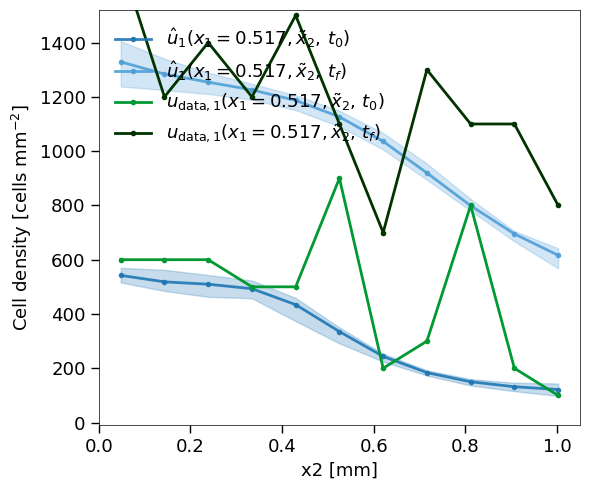

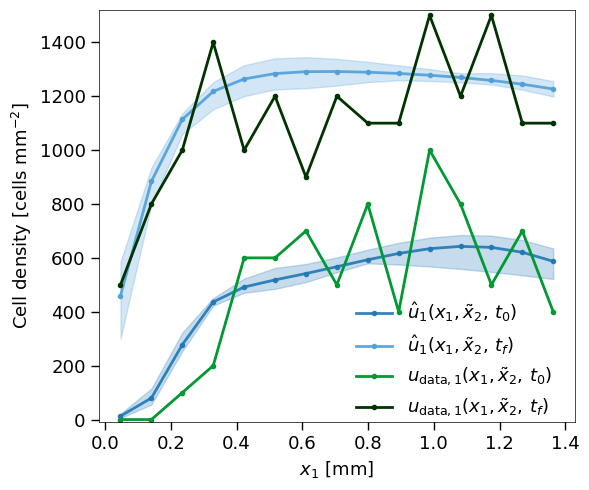

In [13]:
# =======================================================================================
# For chosen replicate plotting density slices at t=0,T and fixed x1 & x2 slices
# =======================================================================================

plotter = MidlinePlotter(device="cpu")
chosen_key2 = "2_5"
x1_idx = 5
x2_idx = 1
x4opt_save = 2
x5opt_save = 5
chosen_key2 = f"{x4opt_save}_{x5opt_save}"

# Match the same figures/main folder style used by other main plots
midline_base_dir = os.path.join(
    FIGURES_MAIN_DIR,
    f"key_{chosen_key2}_x4_{x4opt_save}_x5_{x5opt_save}",
)

_ = plotter.plot_midline_prediction_vs_data(
    model_wrappers=binn_models_dics[chosen_key2],
    dataobj=dataObj_dict[chosen_key2],
    species_label=speciesLabel,
    K=1,
    save_name="data_and_u_hat.png",
    save_dic={},
    base_dir=midline_base_dir,
    overwrite=True,
    legend_fontsize=13,
    legend_ncols=1,
    figsize=(6, 5),
    legend_loc_x1=(0.525, -0.01),
    x1_idx=x1_idx,
    x2_idx=x2_idx,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    xtick_labelsize=13,
    ytick_labelsize=13,
    tick_length=6,
    tick_width=1,
    minor_tick_length=3,
    ylim = [-10,1520],
    minor_tick_width=0.0)




## Gif of D and G over epochs

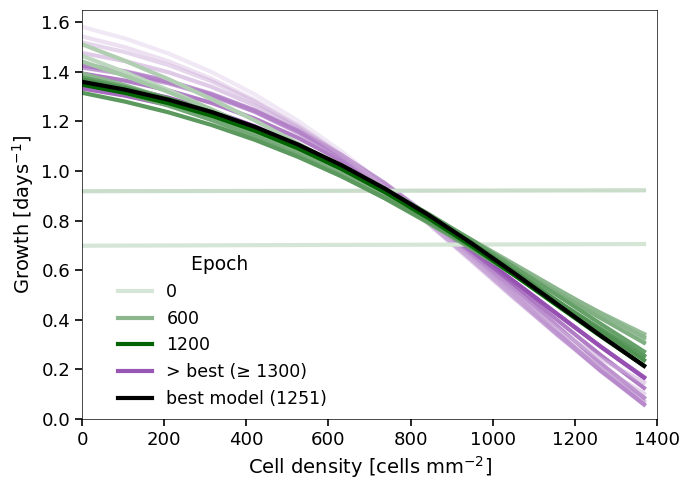

Saved growth plot for 2_5, model_index=0: outputs/figures/main/key_2_5_x4_2_x5_5/DGgif_growth_2_5_model0.png


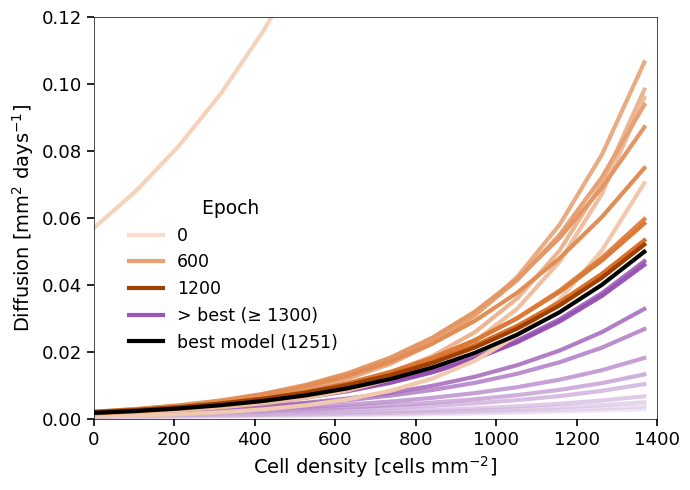

Saved diffusion plot for 2_5, model_index=0: outputs/figures/main/key_2_5_x4_2_x5_5/DGgif_diffusion_2_5_model0.png


In [14]:
plotter = TrainingDynamicsPlotter(
    device="cpu",
    gray_base_color="#8E44AD",
)

chosen_key2 = "2_5"
chosen_TV = 3  # 0,1,2,3,4

save_path1 = os.path.join(FIGURES_MAIN_DIR, f"key_{chosen_key2}_x4_{x4opt_save}_x5_{x5opt_save}")

plotter.plot_single_run_growth_diffusion_over_training(
    model_wrapper_groups={chosen_key2: {chosen_TV: binn_models_dics1000[chosen_key2][chosen_TV]}},
    dataobj=dataObj_dict[chosen_key2],
    species_label=speciesLabel,
    save_dic={},
    base_dir=save_path1,
    save_name="DGgif.gif",
    labels=form_labels(keys),
    num_bins=50,
    K=1,
    figsize=(7, 5),
    legend_pos_diffusion=(0.05, 0.15),
    legend_pos_growth=(0.05, 0.01),
    legend_fontsize=12.5,
    legend_ncols=1,
    axis_labels=True,

    # New explicit axis/tick styling
    xlabel_fontsize=14,
    ylabel_fontsize=14,
    xtick_labelsize=13,
    ytick_labelsize=13,
    major_tick_length=5.0,
    major_tick_width=1.2,
    minor_tick_length=3.0,
    minor_tick_width=0.8,

    overwrite=True,
    y_lim_growth=[0.0, 1.65],
    y_lim_diffusion=[0, 0.12],
    model_index=0,
    x_lim=[0, 1400],
    save_dir2=None,
    epoch_step=10,
    epochs_sf=10,
)


Selected replicate 2 | key = 2_3
Configurations loaded:
  ES = 500        | runs = 5
  ES = 1000       | runs = 5
  ES = 2000       | runs = 5

Validation loss and total learning time summary

--- Summary ---
            500 | val loss: mean=0.01305, range=[0.01248, 0.01337] | time: mean=141.3 s, range=[118.5, 164.1] s
           1000 | val loss: mean=0.01267, range=[0.01122, 0.01337] | time: mean=288.7 s, range=[179.3, 398] s
           2000 | val loss: mean=0.01225, range=[0.01122, 0.01266] | time: mean=568.4 s, range=[504.2, 632.7] s



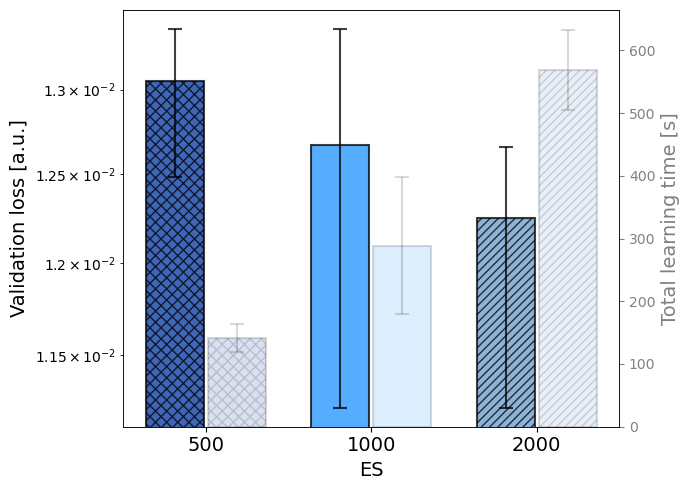

In [15]:
# =======================================================================================
# For chosen replicate plot & print final validation loss and total learning time
# =======================================================================================
from paper_helpers.plotting.training_summary import TrainingSummaryPlotter
summary_plotter = TrainingSummaryPlotter()

# ---- choose replicate index ----
chosen_index2 = 1
chosen_key2 = keys[chosen_index2]

print("\n" + "=" * 100)
print(f"Selected replicate {chosen_index2 + 1} | key = {key}")
print("=" * 100)

print("Configurations loaded:")
for es, model_dict in binn_models_combined.items():
    print(f"  ES = {es:<10} | runs = {len(model_dict)}")

# ---- plot ----
summary_plotter.plot_loss_and_runtime_summary(
    models_dics_list=[binn_models_combined],
    plot_params=plot_params,
    label_list=["Summary"],
    hatch_patterns=("xxx", "", "////", "\\\\", "xxxx", "++++", "....", "ooo"),
    name=None,  # or name_full
    intra_spacing=0.15,
    inter_spacing=0.40,
    legend_bool=False,
    figsize=(7, 5),
    x_label=r"ES",
    y2_label="Total learning time [s]",
    alpha=0.15,
    print_summary=True,
    print_precision=4,
)

In [16]:
# =========================================================================================
# Forward solve for all replicates and TV splits using respective diffusion and growth MLPs
# =========================================================================================
from paper_helpers.simulation.forward_batch import forward_simulate_learned_DG

for index in range(num_replicates):

    results = forward_simulate_learned_DG(
        keys=keys,
        dataObj_dict=dataObj_dict,
        binn_ES_list=binn_ES_list,
        binnSplitSeeds=binnSplitSeeds,
        binn_exts=binn_exts,
        binn_models_dics_ES=binn_models_dics_ES,
        speciesLabel=speciesLabel,
        key_idx=index,
        device="cpu",
        forward_sim_bool=True,
        overwrite_forward=False,
        init_type="pred",
        base_dir=FWD_OUTPUT_DIR,
    )

[INFO] Using key: 2_3 (index=0), device=cpu

##### Forward learned DG for ES = 500 #####

--- Simulation: key=2_3, ES=500, seed=0 ---
[SKIP] File exists: outputs/forward/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_3/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_0/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/ufwd_initpred.npy

--- Simulation: key=2_3, ES=500, seed=1 ---
[SKIP] File exists: outputs/forward/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_3/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]/gamma_0/K_1/binnVF_0.2/b

Total loss trajectories for 2_5


/Users/willa954/Desktop/Git-public/experim_copliot/Training/JN/paper_helpers/plotting/loss_trajectories.py:434: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


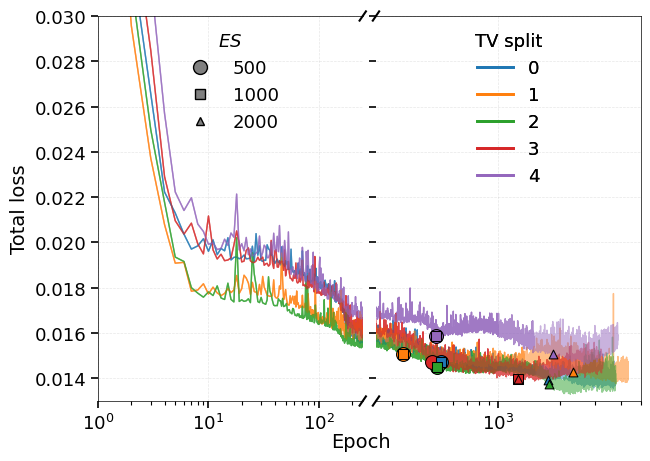

Data loss trajectories for 2_5


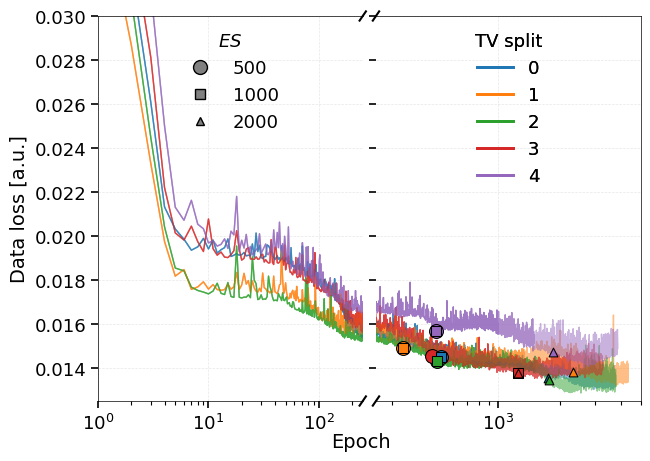

PDE loss trajectories for 2_5


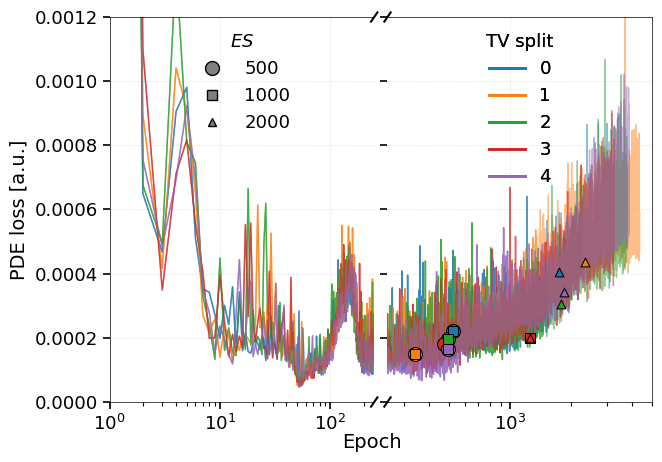

In [17]:
# =========================================================================================
# Plot PDE and data losses across replicates for each ES \in [500,1000,2000]
# =========================================================================================


chosen_key3 = "2_5"
es_plotter = EarlyStoppingTrajectoryPlotter()

es_plotter.plot_loss_trajectories_across_early_stopping(
    models_dics_list=[{chosen_key3: binn_models_dics_ES[es][chosen_key3]} for es in binn_ES_list],
    es_list=binn_ES_list,
    use_val_loss=True,
    yscale=None,
    xscale="log",
    ylim_total=(1.3e-2, 3e-2),
    ylim_data=(1.25 * 1e-2, 3e-2),
    ylim_pde=(0, 1.2e-3),
    xlim_left=(1, 250),
    xlim_right=(250, 5000),
    figsize=(7, 5),
    base_cmap="Blues",
    es_marker_map=None,
    title=None,
    base_dir=save_path1,

    # Axis/tick styling
    xlabel_fontsize=14,
    ylabel_fontsize=14,
    xtick_labelsize=13,
    ytick_labelsize=13,
    major_tick_length=5.0,
    major_tick_width=1.2,
    minor_tick_length=3.0,
    minor_tick_width=0.8,

    # Legend placement
    total_legend_loc_repeat="upper center",
    total_legend_loc_es="upper center",
    data_legend_loc_repeat="upper center",
    data_legend_loc_es="upper center",
    pde_legend_loc_repeat="upper center",
    pde_legend_loc_es="upper center",

    # Legend font sizes: total-loss panel
    total_repeat_legend_fontsize=13,
    total_repeat_legend_title_fontsize=13,
    total_es_legend_fontsize=13,
    total_es_legend_title_fontsize=13,

    # Legend font sizes: data-loss panel
    data_repeat_legend_fontsize=13,
    data_repeat_legend_title_fontsize=13,
    data_es_legend_fontsize=13,
    data_es_legend_title_fontsize=13,

    # Legend font sizes: PDE-loss panel
    pde_repeat_legend_fontsize=13,
    pde_repeat_legend_title_fontsize=13,
    pde_es_legend_fontsize=13,
    pde_es_legend_title_fontsize=13,
)

## Symbolic Diffusion

### PySR

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython

[1/3] key=2_3
Checking file existence for this case...
Loading from outputs/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_3/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_4/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/diff_SR_densityScalingdimensionless_yScalingdimensionless_predSFTrue_pop50_con{}_maxsize10_parsimony0_model_selectionbest_niter25_percentiles[5, 95]_seeds[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_loss(x - y)^2_ops['log', 'exp', 'sqrt'].pkl...

[1/3] key=2_3
LOAD took 00:00:00 | Elapsed: 0

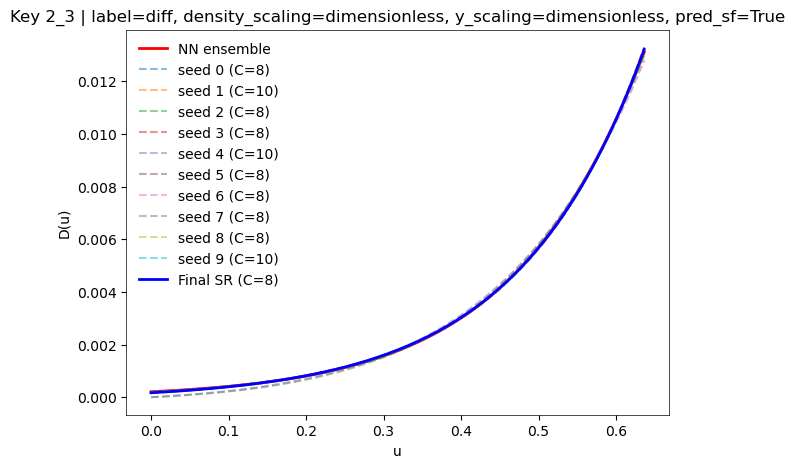

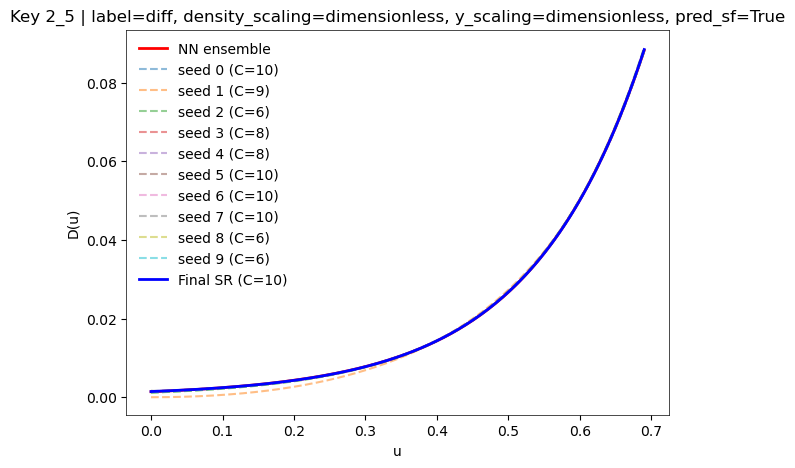

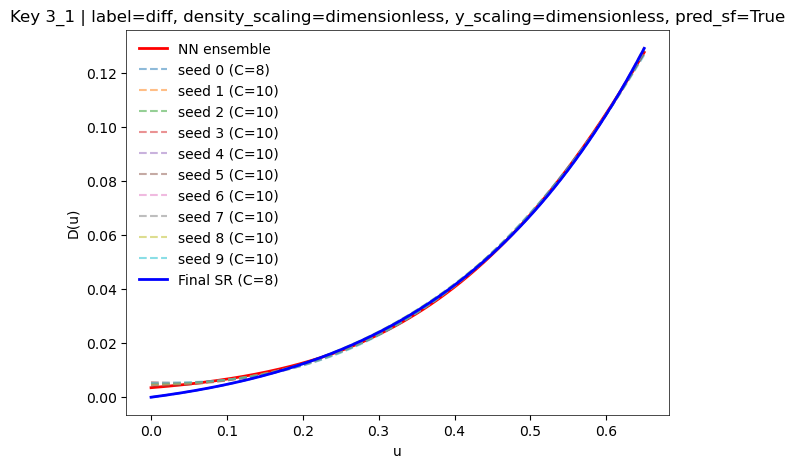

In [18]:
from paper_helpers.sr.batch import SymbolicRegressionBatchRunner

import warnings
# Filter out the specific UserWarning from pysr about using Jupyter 
warnings.filterwarnings("ignore", category=UserWarning, module="pysr")

# --- SR Infrastructure & Scaling ---
SR_device          = "cpu"
SR_yscaling        = "dimensionless"
SR_density_scaling = "dimensionless"

# --- Evolution & Search Space ---
SR_niter           = 25
SR_seeds           = range(10)
SR_pop_size        = 50 
SR_max_size        = 10
SR_parsimony       = 0
SR_percentiles     = [5, 95]
ES = 500


# --- Math & Objectives ---
SR_loss            = "(x - y)^2"
SR_unary_ops       = ["log", "exp", "sqrt"]
SR_binary_ops      = ["+", "-", "*", "/"]
SR_constraints     = {}
SR_model_selection = "best"

# --- Logging & Flags ---
SR_verbose         = 1
SR_use_sf          = True

# --- The Runner Initialization ---
runner_diff = SymbolicRegressionBatchRunner(
    label=                  "diff",
    keys=                   keys,
    dataObj_dict=           dataObj_dict,
    binn_models_dics_ES=    binn_models_dics_ES,
    binn_exts=              binn_exts,
    ES=                     ES,
    binnSplitSeeds=         binnSplitSeeds,
    build_save_base=        build_save_base,
    # Variable Mappings:
    device=                 SR_device,
    density_scaling=        SR_density_scaling,
    y_scaling=              SR_yscaling,
    use_sf_for_predictions= SR_use_sf,
    population_size=        SR_pop_size,
    percentiles=            SR_percentiles,
    niter=                  SR_niter,
    seeds=                  SR_seeds,
    loss=                   SR_loss,
    unary_operators=        SR_unary_ops,
    binary_operators=       SR_binary_ops,
    constraints=            SR_constraints,
    maxsize=                SR_max_size,
    parsimony=              SR_parsimony,
    model_selection=        SR_model_selection,
    verbose=                SR_verbose,
    base_dir=               SR_OUTPUT_DIR
)


# run without plotting
runner_diff.run(plot=False)

# plot later
runner_diff.plot_runs()

# or do both in one call
# runner.run(plot=True)

results_diff = runner_diff.get_results()
D_SR_runs = results_diff["D_SR_runs_by_key"]


In [19]:
from paper_helpers.sr.analysis import SymbolicRegressionSeedReporter

EXCLUSIONS_MAP = {
    "2_3": [],
    "2_5": [],
    "3_1": [],
}

reporter_diff = SymbolicRegressionSeedReporter(
    SR_runs=D_SR_runs,
    keys=keys,
    label = "diff",
    exclusions_map=EXCLUSIONS_MAP,
)

# 1. Print summaries and build rankings
results_by_key = reporter_diff.analyze(verbose=True)

# 2. Count forms
global_form_counts = reporter_diff.expression_form_counts(
    include_excluded=False,
    per_key=False,
    verbose=True,
)

per_key_form_counts = reporter_diff.expression_form_counts(
    include_excluded=False,
    per_key=True,
    verbose=True,
)

# 3. NEW: Best expression within each form, based on ordinary MSE
global_best_per_form = reporter_diff.best_expression_per_form(
    include_excluded=False,
    per_key=False,
    sort_by="count",   # or "mse"
    verbose=True,
)

per_key_best_per_form = reporter_diff.best_expression_per_form(
    include_excluded=False,
    per_key=True,
    sort_by="count",   # or "mse"
    verbose=True,
)

# # 4. Plot raw-space fits and residuals
# reporter_diff.plot_runs()

# # 5. Optional structured summary
# summary_diff = reporter_diff.global_summary()
# print(summary_diff)


CLEANED D SYMBOLIC EXPRESSIONS & WEIGHTED-FIT RANKING

>>> KEY: 2_3
    Excluding seeds from stats: []
  [Seed  0] D(x0) = 0.00026989094*exp(6.12575476190141*x0) - 0.000101576974
  [Seed  1] D(x0) = (0.0005781232*x0 + 0.0001787222)*exp(4.99813069911853*x0)
  [Seed  2] D(x0) = 0.0014569749*x0*exp(4.14636038497629*x0)
  [Seed  3] D(x0) = 0.00024874017*exp(6.2569056*x0) - 4.3453747e-5
  [Seed  4] D(x0) = 0.00157286774*x0*exp(4.003203*x0)
  [Seed  5] D(x0) = 0.00025071783*exp(6.2441487*x0) - 4.897605e-5
  [Seed  6] D(x0) = 0.00027266413*exp(6.1094136*x0) - 0.0001093544
  [Seed  7] D(x0) = 0.00026955153*exp(6.127845*x0) - 0.00010095744
  [Seed  8] D(x0) = 0.0002543799*exp(6.220884*x0) - 5.928309e-5
  [Seed  9] D(x0) = (0.00045865803*x0 + 0.000197599419411024)*exp(5.17561401802635*x0)

  --- Final Ranked Seeds (Best to Worst Weighted Fit) ---
    Rank  1: Seed  1 | W-MSE: 2.6530e-10 | MSE: 2.9468e-10 | Runtime: 5.6 s | Expr: (0.0005781232*x0 + 0.0001787222)*exp(4.99813069911853*x0)
    Rank


[1/3] key=2_3
Checking file existence for this case...
Loading from outputs/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_3/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_4/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/grow_SR_densityScalingdimensionless_yScalingdimensionless_predSFTrue_pop50_con{}_maxsize10_parsimony0_model_selectionbest_niter25_percentiles[5, 95]_seeds[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_loss(x - y)^2_ops['log', 'exp', 'sqrt'].pkl...

[1/3] key=2_3
LOAD took 00:00:00 | Elapsed: 00:00:00 | ETA: 00:00:00 (estimated remaining: 2.0 load, 0.0 compute)
Scaling: density_scaling=dimensionless, y_sca

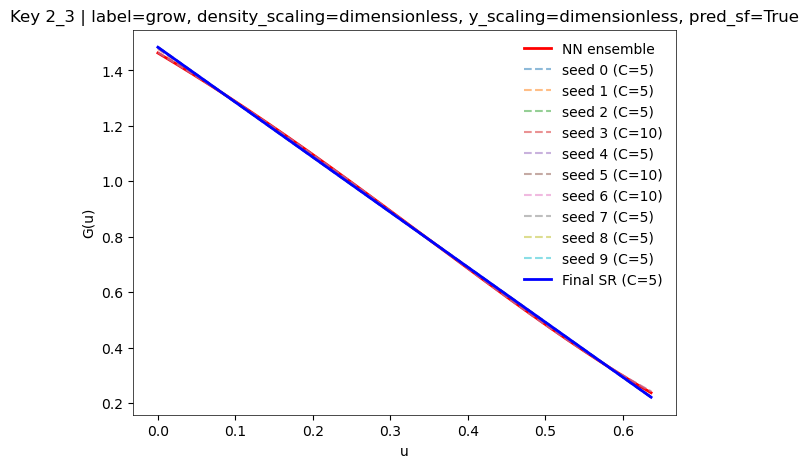

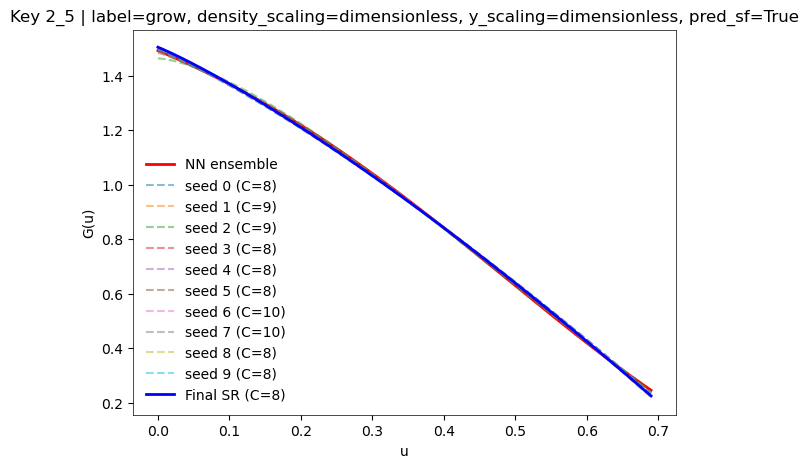

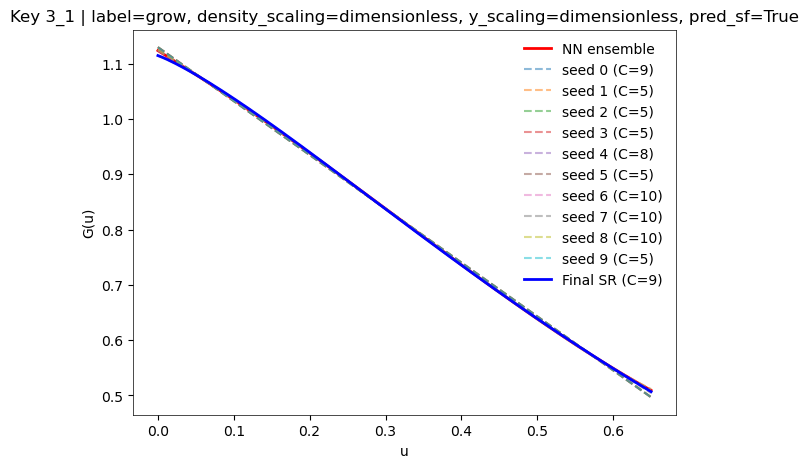

In [20]:

# --- The Runner Initialization ---
runner_grow = SymbolicRegressionBatchRunner(
    label=                  "grow",
    keys=                   keys,
    dataObj_dict=           dataObj_dict,
    binn_models_dics_ES=    binn_models_dics_ES,
    binn_exts=              binn_exts,
    ES=                     ES,
    binnSplitSeeds=         binnSplitSeeds,
    build_save_base=        build_save_base,
    # Variable Mappings:
    device=                 SR_device,
    density_scaling=        SR_density_scaling,
    y_scaling=              SR_yscaling,
    use_sf_for_predictions= SR_use_sf,
    population_size=        SR_pop_size,
    percentiles=            SR_percentiles,
    niter=                  SR_niter,
    seeds=                  SR_seeds,
    loss=                   SR_loss,
    unary_operators=        SR_unary_ops,
    binary_operators=       SR_binary_ops,
    constraints=            SR_constraints,
    maxsize=                SR_max_size,
    parsimony=              SR_parsimony,
    model_selection=        SR_model_selection,
    verbose=                SR_verbose,
    base_dir=               SR_OUTPUT_DIR
)



# run without plotting
runner_grow.run(plot=False)

# plot later
runner_grow.plot_runs()

# or do both in one call
# runner.run(plot=True)

results_grow = runner_grow.get_results()
G_SR_runs = results_grow["G_SR_runs_by_key"]


CLEANED G SYMBOLIC EXPRESSIONS & WEIGHTED-FIT RANKING

>>> KEY: 2_3
    Excluding seeds from stats: []
  [Seed  0] G(x0) = 1.4838518 - 1.9834936*x0
  [Seed  1] G(x0) = 1.4838561 - 1.9835113*x0
  [Seed  2] G(x0) = 1.483855 - 1.9835109*x0
  [Seed  3] G(x0) = (1.3747113*x0 - 3.268832)*exp(1.0*x0) + 4.7464914
  [Seed  4] G(x0) = 1.4838496695875 - 1.9834859*x0
  [Seed  5] G(x0) = 1.46477873949316*exp(-0.42695802*x0*exp(exp(1.0*x0)))
  [Seed  6] G(x0) = 1.46478525777305*exp(-0.42695847*x0*exp(exp(1.0*x0)))
  [Seed  7] G(x0) = 1.4838505 - 1.9834933*x0
  [Seed  8] G(x0) = 1.4838516 - 1.9834938*x0
  [Seed  9] G(x0) = 1.4838545 - 1.9835109*x0

  --- Final Ranked Seeds (Best to Worst Weighted Fit) ---
    Rank  1: Seed  6 | W-MSE: 5.2351e-07 | MSE: 1.0782e-06 | Runtime: 5.3 s | Expr: 1.46478525777305*exp(-0.42695847*x0*exp(exp(1.0*x0)))
    Rank  2: Seed  5 | W-MSE: 5.2425e-07 | MSE: 1.0782e-06 | Runtime: 5.9 s | Expr: 1.46477873949316*exp(-0.42695802*x0*exp(exp(1.0*x0)))
    Rank  3: Seed  3 | 

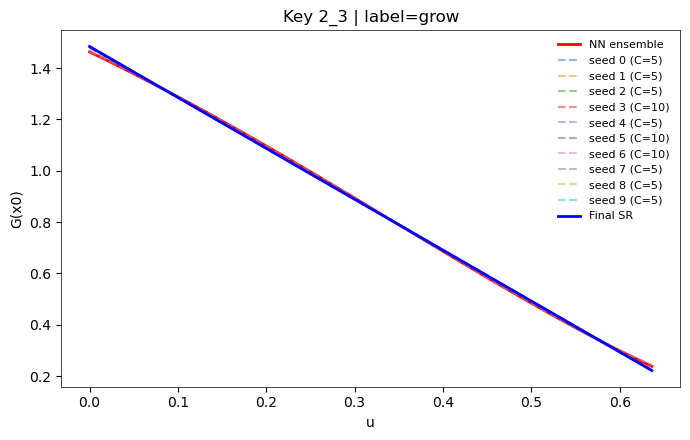

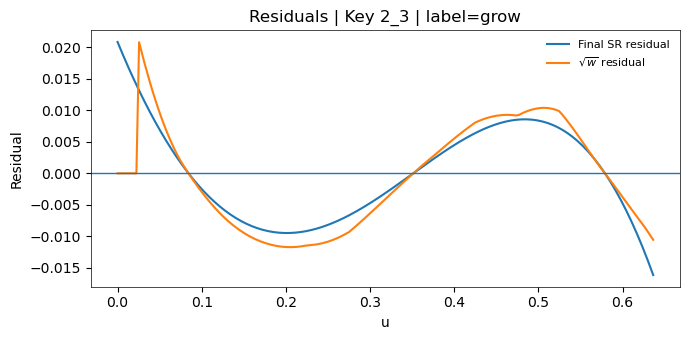

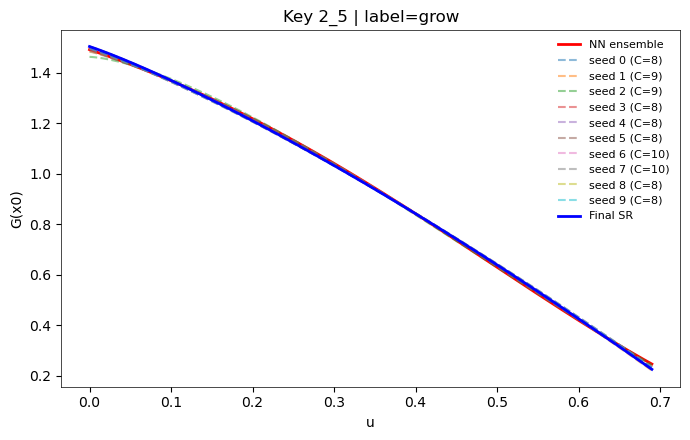

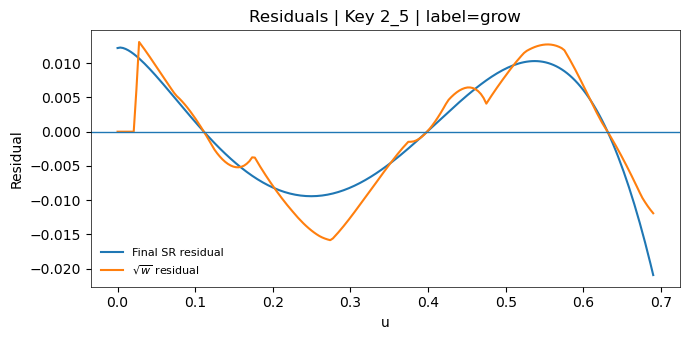

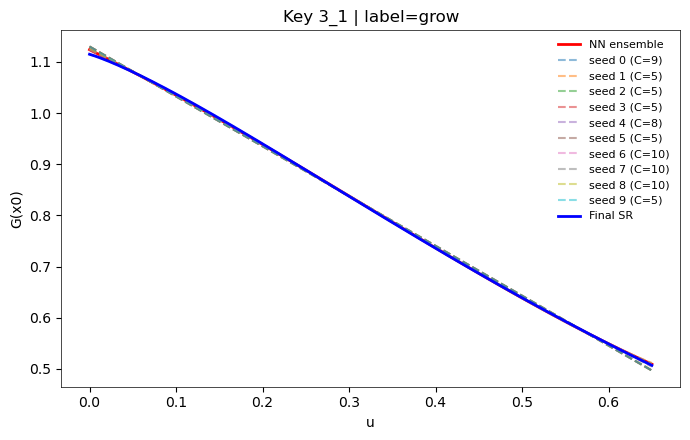

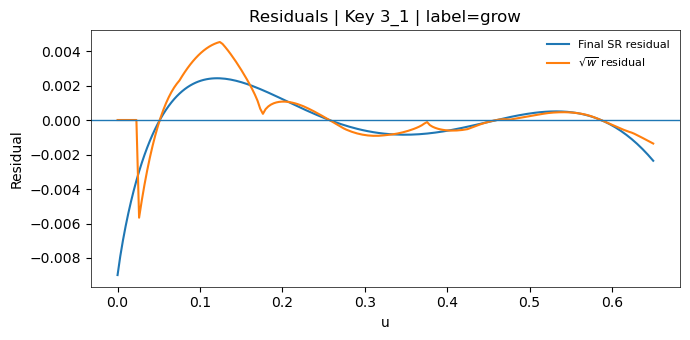

{'all_processed_seeds': '5.2 ± 0.3 s', 'all_kept_seeds': '5.2 ± 0.3 s'}


In [21]:

EXCLUSIONS_MAP = {
    "2_3": [],
    "2_5": [],
    "3_1": [],
}

reporter_grow = SymbolicRegressionSeedReporter(
    SR_runs=G_SR_runs,
    keys=keys,
    exclusions_map=EXCLUSIONS_MAP,
    label="grow",
)

# 1. Print summaries and build rankings
results_by_key = reporter_grow.analyze(verbose=True)

# 2. Table of symbolic-expression form counts
global_form_counts_grow = reporter_grow.expression_form_counts(
    include_excluded=False,
    per_key=False,
    verbose=True,
)

per_key_form_counts_grow = reporter_grow.expression_form_counts(
    include_excluded=False,
    per_key=True,
    verbose=True,
)

# 3. Table of best expression per form, where "best" = lowest ordinary MSE
global_best_per_form_grow = reporter_grow.best_expression_per_form(
    include_excluded=False,
    per_key=False,
    sort_by="count",   # or "mse" or "form"
    verbose=True,
)

per_key_best_per_form_grow = reporter_grow.best_expression_per_form(
    include_excluded=False,
    per_key=True,
    sort_by="count",   # or "mse" or "form"
    verbose=True,
)

# 4. Plot raw-space fits and residuals
reporter_grow.plot_runs()

# 5. Optional structured summary
summary_grow = reporter_grow.global_summary()
print(summary_grow)

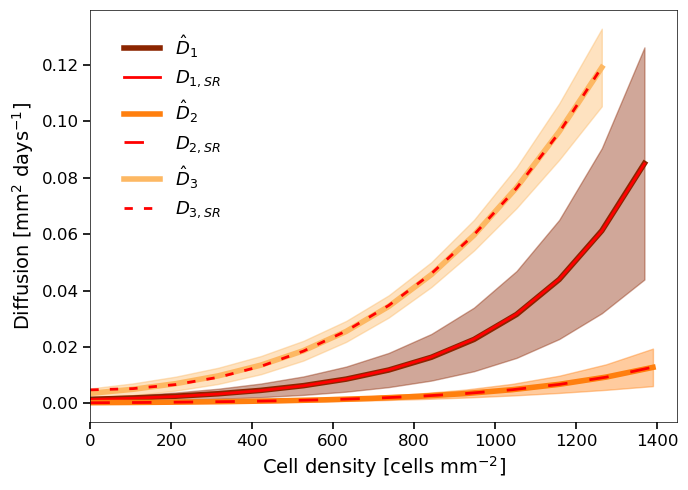

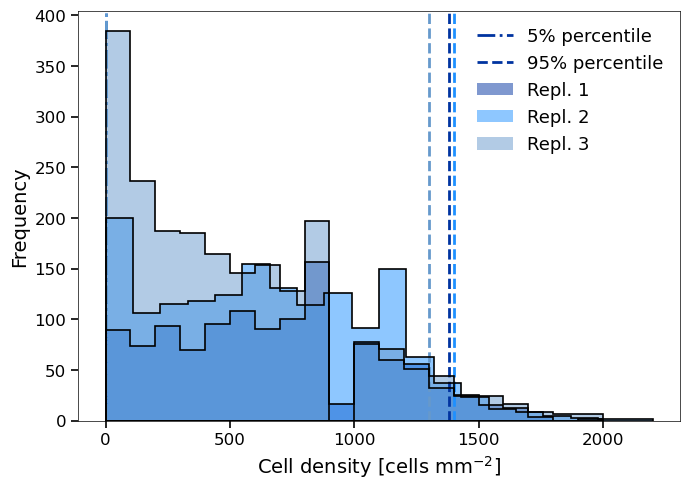

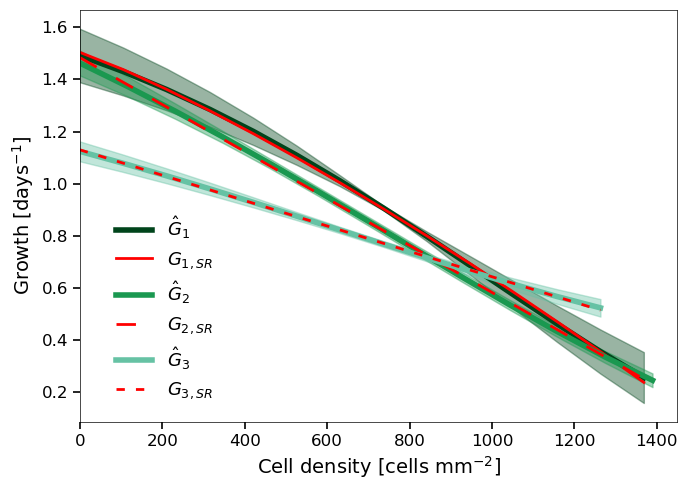

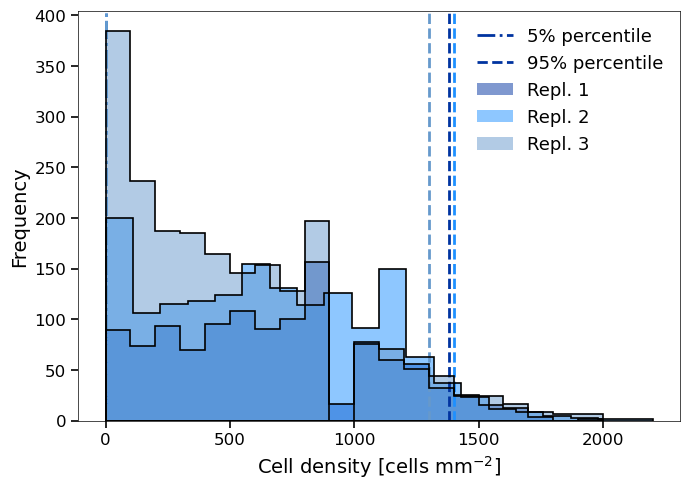

In [22]:

import sympy as sp

x = sp.Symbol("U")

# ------------------------------------------------------------------
# Symbolic-regression objects keyed by replicate/data key
# ------------------------------------------------------------------
D_sym_simp_rounded = {
    "2_3": 0.0002699 * sp.exp(6.126 * x) - 0.0001016,
    "2_5": 0.001159 * sp.exp(6.274 * x) + 0.0001714,
    "3_1": 0.1527 * x**2 * sp.exp(1.000 * x) + 0.004755,
}

G_sym_simp_rounded = {
    "2_3": 1.484 - 1.983 * x,
    "2_5": -1.000 * x**sp.Rational(3, 2) - 1.024 * x + 1.504,
    "3_1": 1.130 - 0.9744 * x,
}

d_lambdas = {
    key: sp.lambdify(x, expr, "numpy")
    for key, expr in D_sym_simp_rounded.items()
}

g_lambdas = {
    key: sp.lambdify(x, expr, "numpy")
    for key, expr in G_sym_simp_rounded.items()
}

D_sym_simp_rounded_latex = {
    key: sp.latex(expr)
    for key, expr in D_sym_simp_rounded.items()
}

G_sym_simp_rounded_latex = {
    key: sp.latex(expr)
    for key, expr in G_sym_simp_rounded.items()
}

# ------------------------------------------------------------------
# Select models in the desired plotting/display order
# ------------------------------------------------------------------
selected_keys = ["2_5", "2_3", "3_1"]
selected_models = {k: binn_models_dics[k] for k in selected_keys}
selected_d_lambdas = {k: d_lambdas[k] for k in selected_keys}
selected_g_lambdas = {k: g_lambdas[k] for k in selected_keys}
selected_D_sym = {k: D_sym_simp_rounded_latex[k] for k in selected_keys}
selected_G_sym = {k: G_sym_simp_rounded_latex[k] for k in selected_keys}

# u_scale_SRs will always be filled with 1s here since we apply PySR to
# normalised densities (normalisation specific to each replicate)
selected_u_scale_SRs = {k: results_grow["u_scale_SRs"][k] for k in selected_keys}

# Create plotter once
sr_plotter = SRPlotter(
    base_dir=save_path1,
    overwrite=True,
    dpi=100,
)

# Shared plotting configuration
common_plot_params = {
    "save_dic": {},
    "save_dir2": "",
    "speciesLabel": speciesLabel,
    "device": "cpu",
    "num_bins": 20,
    "K": 1,
    "legend_fontsize": 13,
    "x_lim": (0, 1450),
    "u_scale_SRs": selected_u_scale_SRs,
    "show_hist": True,
    "save_hist": True,
    "hist_clip_5_95": False,
    "range5_95": True,

    # Main curve plot sizing
    "xlabel_fontsize": 14,
    "ylabel_fontsize": 14,
    "xtick_labelsize": 12,
    "ytick_labelsize": 12,
    "major_tick_length": 5.0,
    "major_tick_width": 1.2,
    "minor_tick_length": 3.0,
    "minor_tick_width": 0.8,

    # Histogram sizing (separate, optional)
    "hist_xlabel_fontsize": 14,
    "hist_ylabel_fontsize": 14,
    "hist_xtick_labelsize": 12,
    "hist_ytick_labelsize": 12,
    "hist_major_tick_length": 5.0,
    "hist_major_tick_width": 1.2,
    "hist_minor_tick_length": 3.0,
    "hist_minor_tick_width": 0.8   
}

# ------------------------------------------------------------------
# Plot Diffusion (D)
# ------------------------------------------------------------------
sr_plotter.plot_eval_D_multi_std(
    selected_models,
    save_name="best_diff_all_std.png",
    colors=DMLP_colors,
    legend_pos=(0.25, 0.45),
    f_lambdas=selected_d_lambdas,
    D_sym_simp_list=None,
    labels=[r"$\hat{D}_1$", r"$\hat{D}_2$", r"$\hat{D}_3$"],
    hist_labels=["Repl. 1", "Repl. 2", "Repl. 3"],
    sym_labels = {"2_5":r"$D_{1,SR}$",
                  "2_3":r"$D_{2,SR}$",
                  "3_1":r"$D_{3,SR}$"},
    **common_plot_params,
)

# ------------------------------------------------------------------
# Plot Growth (G)
# ------------------------------------------------------------------
sr_plotter.plot_eval_G_multi_std(
    selected_models,
    save_name="best_grow_all_std.png",
    colors=GMLP_colors,
    legend_pos=(0.25, 0.01),
    f_lambdas=selected_g_lambdas,
    G_sym_simp_list=None,
    labels=[r"$\hat{G}_1$", r"$\hat{G}_2$", r"$\hat{G}_3$"],
    hist_labels=["Repl. 1", "Repl. 2", "Repl. 3"],
    sym_labels = {"2_5":r"$G_{1,SR}$",
                  "2_3":r"$G_{2,SR}$",
                  "3_1":r"$G_{3,SR}$"},
    **common_plot_params,
)

In [23]:


forward_SR_bool = True
overwrite_SR_forward = False
init_type = "pred"   # "data" or "pred"

forward_results = run_forward_sr_batch(
    keys=keys,
    dataObj_dict=dataObj_dict,
    binn_models_dics_ES=binn_models_dics_ES,
    binn_exts=binn_exts,
    binnSplitSeeds=binnSplitSeeds,

    # SR functions from SymbolicRegressionBatchRunner outputs
    d_lambdas=selected_d_lambdas,
    g_lambdas=selected_g_lambdas,
    u_scale_SRs=selected_u_scale_SRs,

    # experiment config
    ES=ES,
    speciesLabel=speciesLabel,
    device=SR_device,

    # forward sim config
    forward_SR_bool=forward_SR_bool,
    overwrite_SR_forward=overwrite_SR_forward,
    init_type=init_type,
    u_scale_type=SR_density_scaling,

    # SR settings (must match the runner settings for filename consistency)
    population_size=SR_pop_size,
    niter=SR_niter,
    percentiles=SR_percentiles,
    density_scaling=SR_density_scaling,
    y_scaling=SR_yscaling,
    use_sf_for_predictions=SR_use_sf,
    seeds=SR_seeds,
    loss=SR_loss,
    unary_operators=SR_unary_ops,
    binary_operators=SR_binary_ops,
    constraints=SR_constraints,
    maxsize=SR_max_size,
    parsimony=SR_parsimony,
    model_selection=SR_model_selection,

    # simulation resolution
    numtsim=500,
    numxsim1=100,
    numxsim2=100,

    base_dir=os.path.join(FWD_OUTPUT_DIR, "sr"),
    save_suffix="updated_mean",
)


##### Forward SR simulations for ES = 500 #####

--- Forward SR: key=2_3, ES=500, seed=0 ---
[LOAD] Existing SR forward simulation: outputs/forward/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_3/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_0/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/DGfwdSR_pop50_niter25_updated_mean.npy

--- Forward SR: key=2_3, ES=500, seed=1 ---
[LOAD] Existing SR forward simulation: outputs/forward/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_3/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]

[INFO] key=2_3, ES=500 | PE_binn=3.42% | PE_fwd=4.09% | PE_fwd_sr=3.94%
[INFO] key=2_5, ES=500 | PE_binn=4.81% | PE_fwd=5.58% | PE_fwd_sr=5.63%
[INFO] key=3_1, ES=500 | PE_binn=4.26% | PE_fwd=5.53% | PE_fwd_sr=6.55%
[SAVE] outputs/figures/main/key_2_5_x4_2_x5_5/ALLKEYS_ES500_counts.png


/Users/willa954/Desktop/Git-public/experim_copliot/Training/JN/paper_helpers/plotting/forward_eval.py:423: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


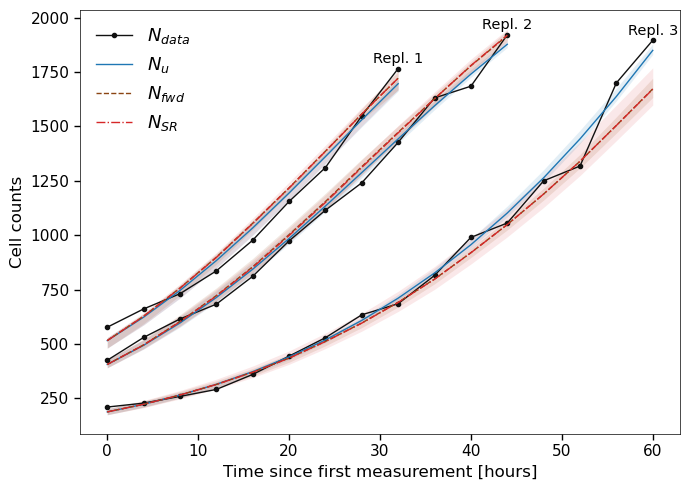

{'2_3': {500: {'key': '2_3',
   'es_val': 500,
   'species_label': 'green',
   'hoursRange': array([ 8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48., 52.]),
   'u_true': array([ 425.,  530.,  615.,  683.,  811.,  974., 1115., 1241., 1427.,
          1631., 1685., 1921.]),
   'u_binn_arr': array([[ 390.45123,  476.49963,  577.0318 ,  691.96765,  820.38306,
            960.5553 , 1109.9646 , 1265.2429 , 1422.352  , 1577.1512 ,
           1726.1348 , 1866.9059 ],
          [ 393.45932,  478.70398,  578.4288 ,  692.61975,  820.4258 ,
            960.12573, 1109.2114 , 1264.5587 , 1422.6592 , 1579.8689 ,
           1732.6484 , 1877.7748 ],
          [ 403.22437,  491.56284,  594.7981 ,  712.4624 ,  843.0113 ,
            983.9052 , 1131.892  , 1283.4238 , 1435.0665 , 1583.7828 ,
           1727.0371 , 1862.7701 ],
          [ 414.1128 ,  502.9568 ,  607.0017 ,  726.0573 ,  858.83014,
           1002.8931 , 1154.8557 , 1310.7128 , 1466.301  , 1617.7351 ,
           1761.6625 , 1895.3556

In [24]:



analyzer = ForwardSimulationAnalysis(
    keys=keys,
    dataInfo_dict=dataInfo_dict,
    dataObj_dict=dataObj_dict,
    speciesLabels=speciesLabels,
    binn_ES_list=[500],
    binn_models_dics_ES=binn_models_dics_ES,
    binn_exts=binn_exts,
    binnSplitSeeds=binnSplitSeeds,
    init_type=init_type,
    save_dir=save_path1,
    save_dir2=None,
    device=SR_device,
    fig_size=(7, 5),
    legend_config=LegendConfig(fontsize=13, ncols=1),
    counts_log_scale=False,
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    xtick_labelsize=11,
    ytick_labelsize=11,
    title_fontsize=11,
    annotation_fontsize=10.5,
    major_tick_length=4.0,
    major_tick_width=1.0,
    minor_tick_length=2.5,
    minor_tick_width=0.8,
    sr_save_params={
        "population_size": SR_pop_size,
        "niter": SR_niter,
        "percentiles": SR_percentiles,
        "density_scaling": SR_density_scaling,
        "y_scaling": SR_yscaling,
        "use_sf_for_predictions": SR_use_sf,
        "seeds": list(SR_seeds),
        "loss": SR_loss,
        "unary_operators": SR_unary_ops,
        "binary_operators": SR_binary_ops,
        "constraints": SR_constraints,
        "maxsize": SR_max_size,
        "parsimony": SR_parsimony,
        "model_selection": SR_model_selection,
        "save_suffix": "updated_mean",
        "verbose": SR_verbose,
    },
    base_dir=FWD_OUTPUT_DIR,
    base_dir_SR=os.path.join(FWD_OUTPUT_DIR, "sr"),
    shift_time_to_zero=True
)

analyzer.run(
    include_sr=True,
    plot_types=["all_keys_counts"]
)